# 02 Hydrogen evolution (IA-HER-001)

**Requirement:** `IA-HER-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

Parasitic charge reaction (EP [0044], [0047]):

$$2\,\mathrm{H_2O} + 2\,\mathrm{e^-} \to \mathrm{H_2} + 2\,\mathrm{OH^-}$$

Coulombic efficiency is

$$\mathrm{CE} = \frac{I_\mathrm{Fe}}{I_\mathrm{Fe} + I_\mathrm{HER}}$$

and falls when the ionic path to the back of a thick iron electrode exceeds
front-surface HER. Vertical channels are a bubble-egress path ([0056]).
Evaluated at $303\,\mathrm{K}$ in $6\,\mathrm{M}$ KOH.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.her import HydrogenEvolution
from plant_sim.components.base import integrate_component

her = HydrogenEvolution(P)
I = -80 * P.I_discharge_100h_A
t, y = integrate_component(
    lambda t, y: her.rhs(
        t, y, {"I_fe_A": I, "T_K": P.T_ep_sim_K, "L_path_m": P.L_anode_m, "a_oh": 6.0, "a_h2o": 0.72}, {}
    ),
    her.y0(),
    (0, 1500),
    n_eval=180,
)
ce = [
    her.outputs(
        float(ti), y[:, i], {"I_fe_A": I, "T_K": P.T_ep_sim_K, "L_path_m": P.L_anode_m, "a_oh": 6.0, "a_h2o": 0.72}, {}
    )["CE"]
    for i, ti in enumerate(t)
]

## Parasitic HER and coulombic efficiency

### What this plot illustrates

Illustrates hydrogen evolution competing with iron charging and the resulting coulombic efficiency $\mathrm{CE}=I_\mathrm{Fe}/(I_\mathrm{Fe}+I_\mathrm{HER})$. Longer ionic paths raise HER (EP [0047]).

### Governing equations

$$2\,\mathrm{H_2O} + 2\,\mathrm{e^-} \to \mathrm{H_2} + 2\,\mathrm{OH^-}$$

$$\mathrm{CE} = \frac{I_\mathrm{Fe}}{I_\mathrm{Fe}+I_\mathrm{HER}}$$


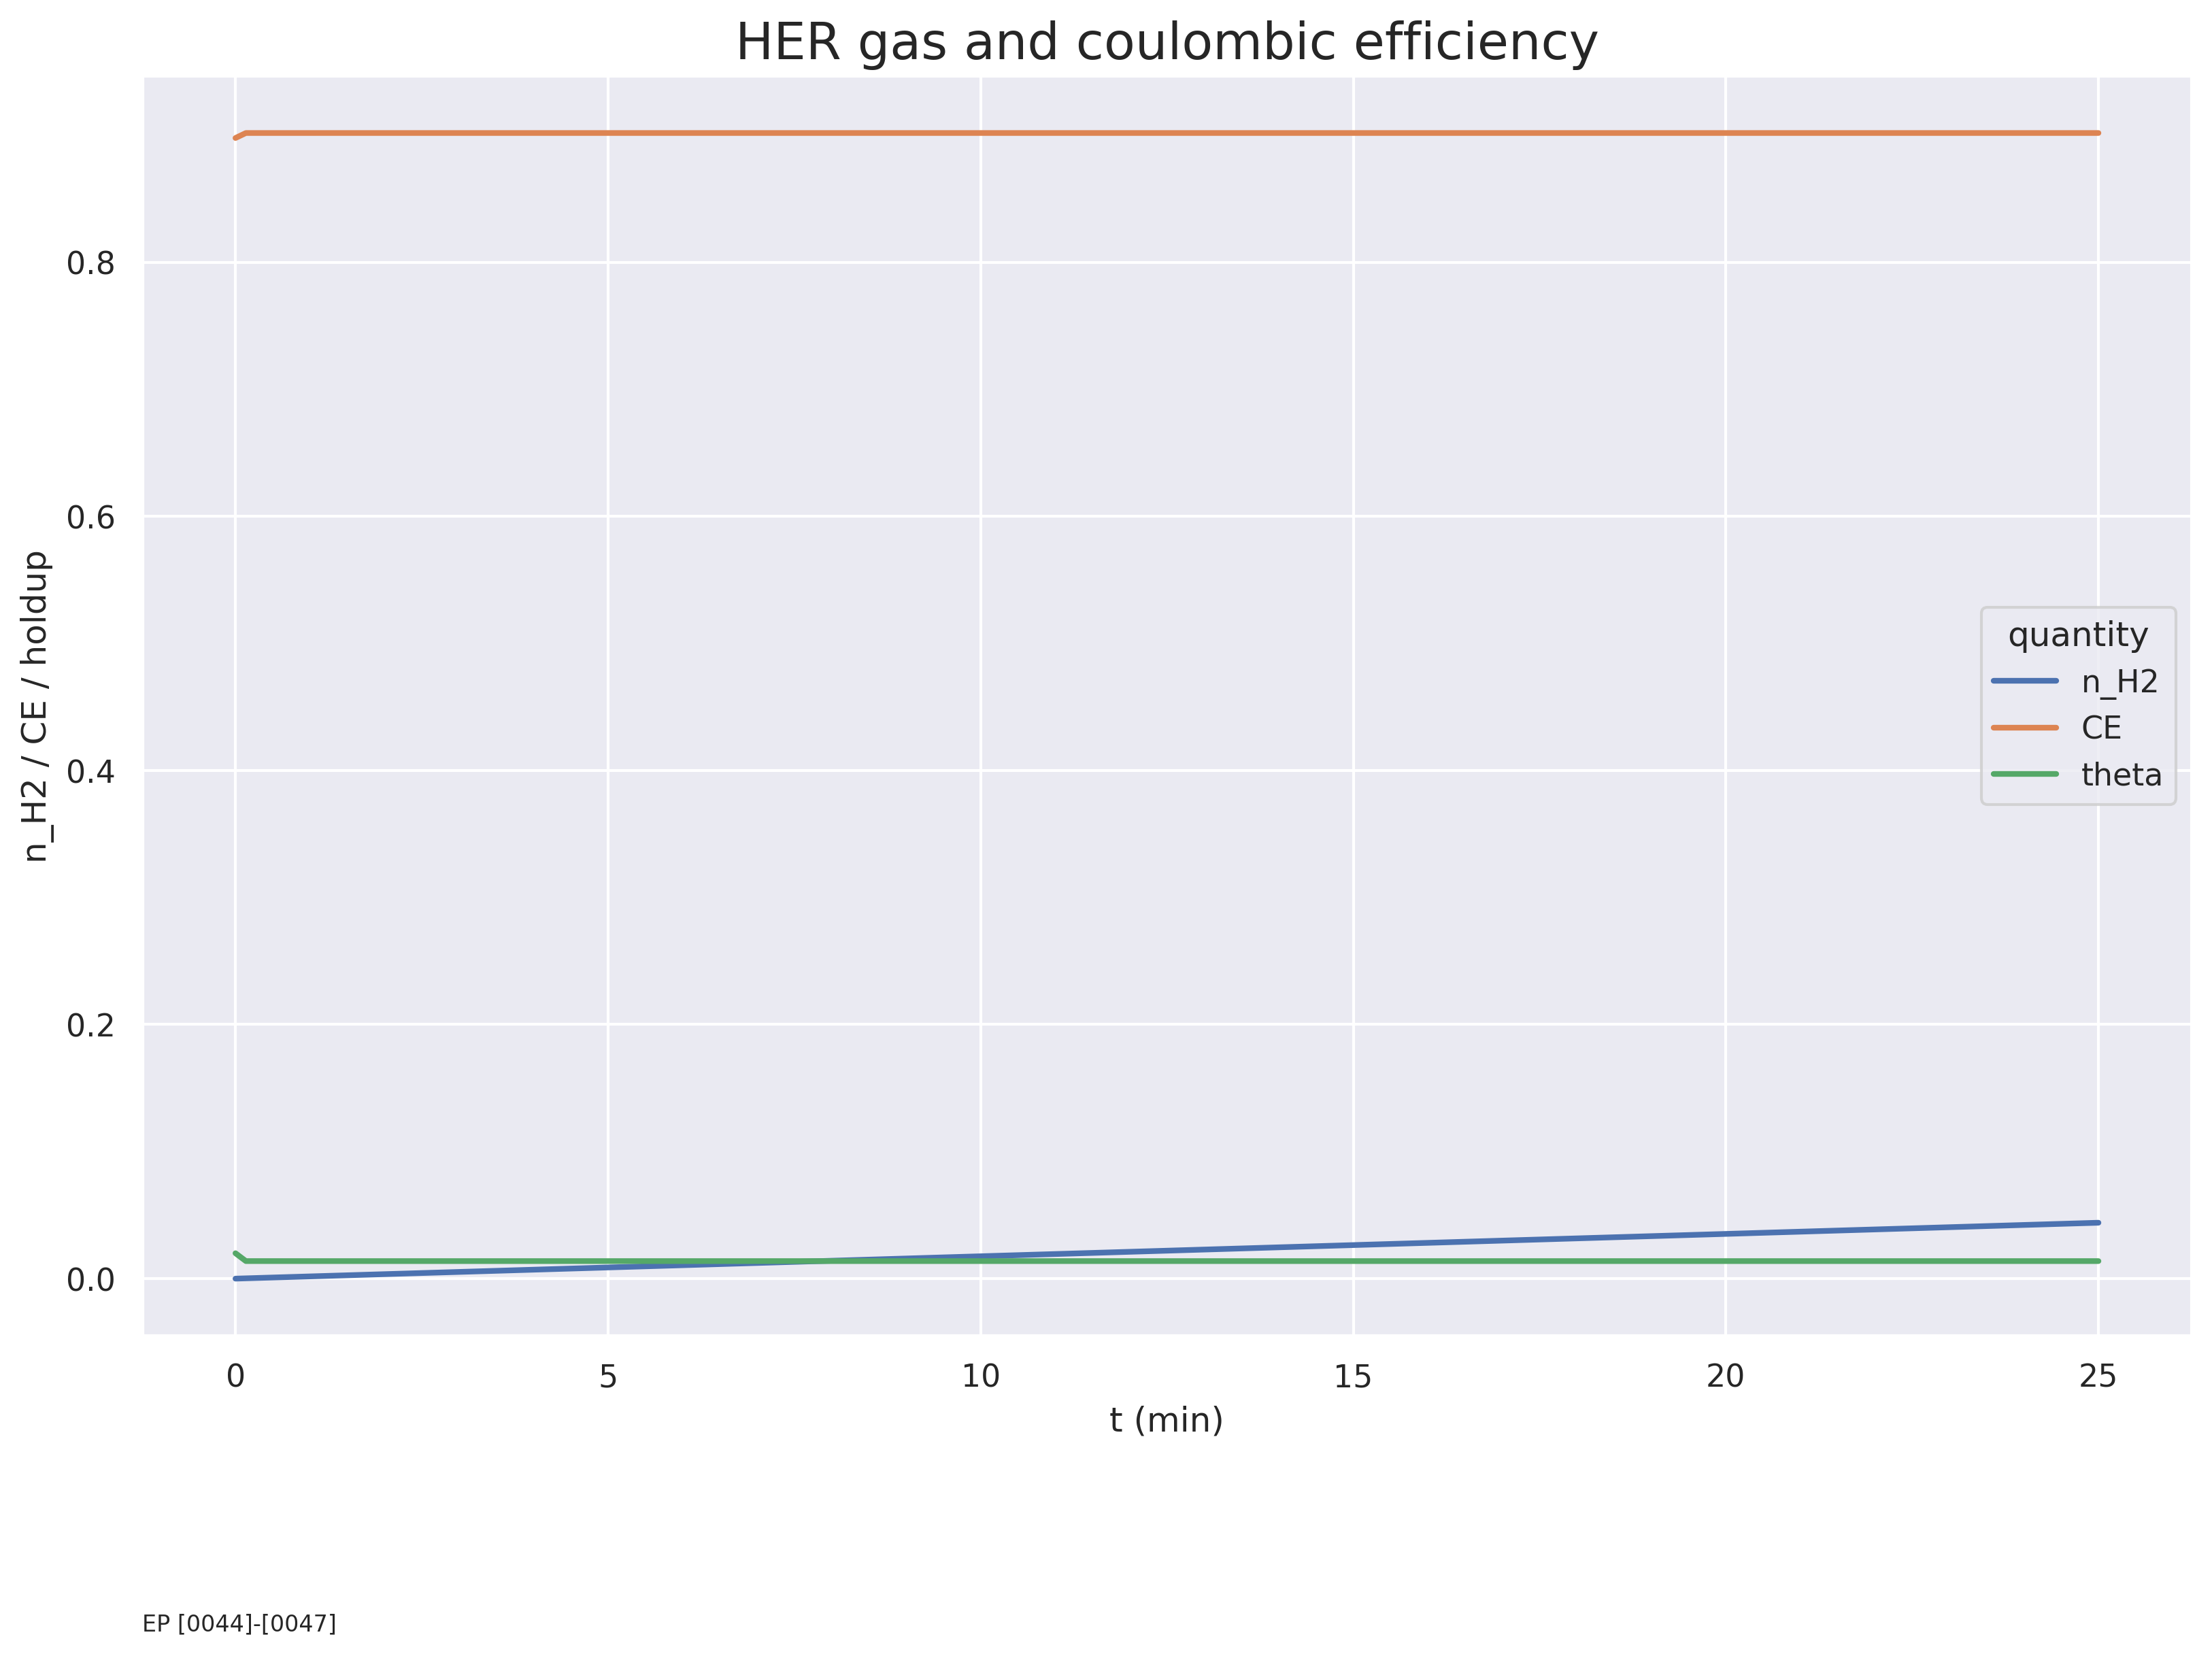

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t / 60),
        "n_H2": (y[0]),
        "CE": (ce),
        "theta": (y[1]),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (min)")
ax.set_ylabel("n_H2 / CE / holdup")
ax.set_title("HER gas and coulombic efficiency")
ax.text(0.0, -0.22, "EP [0044]-[0047]", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Verification against patents / SSS002

In [5]:
print("Open-circuit HER is smaller than strong cathodic charging HER (IA-HER-001 comment).")

Open-circuit HER is smaller than strong cathodic charging HER (IA-HER-001 comment).
